# Projeto: Rede Neural do Zero

**Disciplina:** Matemática para Ciência de Dados  
**Autor:** Emilly Sandy da Costa Santos

---

## 1. Visão Geral e Comparativo

Este trabalho apresenta a implementação e análise de uma rede neural artificial construída do zero (usando apenas **NumPy** e **Matplotlib**), sem o auxílio de bibliotecas de alto nível como TensorFlow ou PyTorch.

O projeto é baseado na refatoração e expansão do `exemplo4.py` visto em aula, transicionando de uma implementação escalar fixada para uma **arquitetura matricial vetorizada** e parametrizável.

### Tabela de Modificações em Relação ao Exemplo Original

| Parâmetro / Aspecto | Exemplo 4 (Original) | Proposta (Este Trabalho) |
| :--- | :--- | :--- |
| **Base de Dados** | Duas Luas (`make_moons`) | Círculos Concêntricos (`make_circles`) |
| **Pré-processamento** | Dados Brutos | **Divisão Treino/Teste (70/30) + StandardScaler** |
| **Camadas Ocultas** | 1 | 1 |
| **Neurônios (Oculta)** | 2 | **8** |
| **Ativação (Oculta)** | Sigmoide | **ReLU** |
| **Ativação (Saída)** | Sigmoide | Sigmoide |
| **Inicialização** | Aleatória Simples (`rand`) | **He Normal** ($\sigma = \sqrt{2/n_{in}}$) |
| **Implementação** | Escalar / Reta Fixa | **Matricial / Vetorizada** |
| **Validação de Gradientes**| Ausente | **Diferenças Finitas + PyTorch (`allclose`)** |

## 2. A Geometria do Problema (`make_circles`)

A base de dados `make_circles` gera dois anéis concêntricos no plano 2D ($x_1, x_2$), onde uma classe ocupa a região central e a outra envolve o círculo externo. Este é um problema não linearmente separável no espaço original.

### Por que a arquitetura baseline falha e a Proposta funciona?

1. **Separação Linear (1 Neurônio):** Um único neurônio calcula $z = w_1 x_1 + w_2 x_2 + b$ e aplica uma decisão pelo sinal. Geometricamente, isso equivale a uma **reta** cortando o plano. Nenhuma reta consegue isolar o círculo interno, gerando uma taxa de erro próxima de 50%.
2. **Capacidade Limitada (2 a 4 Neurônios Ocultos):** Com 2 neurônios, a rede gera no máximo a combinação de duas retas, insuficiente para "fechar" um contorno. Além disso, em redes pequenas com ativação ReLU ($2 \to 4 \to 1$), há alto risco de degradação pelo problema de neurônios mortos (*Dying ReLU*), caso algum neurônio fique inativo durante a inicialização.
3. **Solução Escolhida ($2 \to 8 \to 1$ com ReLU + He Normal):**
   * Aumentamos a camada oculta para **8 neurônios**, garantindo a redundância necessária para evitar os impactos do *Dying ReLU*.
   * Geometricamente, cada neurônio com ativação ReLU constrói um hiperplano que secciona o plano 2D. A combinação das 8 unidades permite que a camada de saída (Sigmoide) projete um **polígono convexo de 8 lados (octógono)** ao redor do círculo central, delimitando as duas classes com alta precisão.

Erro relativo (Diferenças Finitas): 1.24e-11
=== Conferência dos gradientes contra o PyTorch ===
W1: allclose = True | máx. diferença = 0.00e+00
b1: allclose = True

Época     0 | Perda: 0.134486 | Acc Treino: 51.79% | Acc Teste: 48.75%
Época  2000 | Perda: 0.003993 | Acc Treino: 100.00% | Acc Teste: 99.58%
Época  4000 | Perda: 0.001363 | Acc Treino: 100.00% | Acc Teste: 100.00%
Época  6000 | Perda: 0.000881 | Acc Treino: 100.00% | Acc Teste: 100.00%
Época  8000 | Perda: 0.000657 | Acc Treino: 100.00% | Acc Teste: 100.00%
Época  9999 | Perda: 0.000523 | Acc Treino: 100.00% | Acc Teste: 100.00%

=== MATRIZ DE CONFUSÃO (CONJUNTO DE TESTE) ===
[[120   0]
 [  0 120]]

=== RELATÓRIO DE CLASSIFICAÇÃO ===
              precision    recall  f1-score   support

           0      1.000     1.000     1.000       120
           1      1.000     1.000     1.000       120

    accuracy                          1.000       240
   macro avg      1.000     1.000     1.000       240
weighted avg      1.

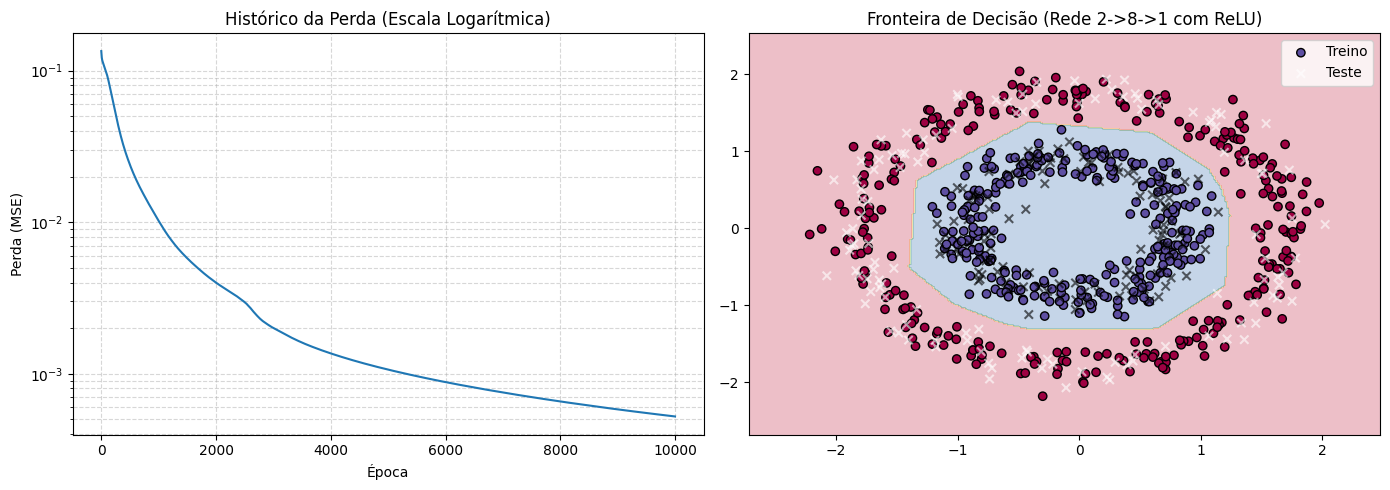

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

# ----------------------------------------------------------------------
# 1. GERAÇÃO E PRÉ-PROCESSAMENTO DO DATASET
# ----------------------------------------------------------------------
def gera_dados(n_samples=600, noise=0.08, factor=0.5, seed=42):
    """
    Gera o dataset de círculos concêntricos e aplica a divisão treino/teste + normalização.
    """
    X, Y = make_circles(n_samples=n_samples, noise=noise, factor=factor, random_state=seed)
    Y = Y.reshape(-1, 1)  # Converte para matriz coluna (N, 1)

    # Divisão 70% Treino e 30% Teste
    X_tr, X_te, Y_tr, Y_te = train_test_split(X, Y, test_size=0.30, random_state=seed, stratify=Y)

    # Padronização (Ajusta o scaler apenas no treino para evitar data leakage)
    scaler = StandardScaler()
    X_tr = scaler.fit_transform(X_tr)
    X_te = scaler.transform(X_te)

    return X_tr, X_te, Y_tr, Y_te

# ----------------------------------------------------------------------
# 2. FUNÇÕES DE ATIVAÇÃO E SUAS DERIVADAS
# ----------------------------------------------------------------------
def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

def relu(z):
    return np.maximum(0, z)

def relu_derivative(z):
    return (z > 0).astype(float)

# ----------------------------------------------------------------------
# 3. INICIALIZAÇÃO DOS PESOS (HE NORMAL)
# ----------------------------------------------------------------------
def inicializa_pesos(camadas, seed=42):
    """
    camadas: [n_in, n_hidden, n_out] -> Exemplo: [2, 8, 1]
    """
    np.random.seed(seed)
    W, b = [], []
    for i in range(len(camadas) - 1):
        n_in, n_out = camadas[i], camadas[i + 1]
        # Inicialização He Normal para ReLU na camada oculta / Xavier na saída
        std = np.sqrt(2.0 / n_in) if i < len(camadas) - 2 else np.sqrt(1.0 / n_in)
        w_camada = np.random.randn(n_in, n_out) * std
        b_camada = np.zeros((1, n_out))
        W.append(w_camada)
        b.append(b_camada)
    return W, b

# ----------------------------------------------------------------------
# 4. FORWARD PASS (PROPAGAÇÃO PARA A FRENTE)
# ----------------------------------------------------------------------
def forward(X, W, b):
    Zs, As = [], [X]
    n_camadas = len(W)

    for i in range(n_camadas):
        Z = As[-1] @ W[i] + b[i]
        A = sigmoid(Z) if i == n_camadas - 1 else relu(Z)
        Zs.append(Z)
        As.append(A)

    return Zs, As

# ----------------------------------------------------------------------
# 5. BACKWARD PASS (RETROPROPAGAÇÃO VETORIZADA)
# ----------------------------------------------------------------------
def backward(Y, W, b, Zs, As):
    n_camadas = len(W)
    N = Y.shape[0]  # Número de amostras

    e = As[-1] - Y
    loss = np.mean(0.5 * (e ** 2))

    grad_W = [None] * n_camadas
    grad_b = [None] * n_camadas

    grad_A = e / N

    for i in reversed(range(n_camadas)):
        if i == n_camadas - 1:
            grad_Z = grad_A * As[i + 1] * (1 - As[i + 1])
        else:
            grad_Z = grad_A * relu_derivative(Zs[i])

        grad_W[i] = As[i].T @ grad_Z
        grad_b[i] = grad_Z.sum(axis=0, keepdims=True)
        grad_A = grad_Z @ W[i].T

    return grad_W, grad_b, loss

# ----------------------------------------------------------------------
# 6. VERIFICAÇÃO NUMÉRICA DO GRADIENTE (DIFERENÇAS FINITAS)
# ----------------------------------------------------------------------
def verifica_gradiente(X, Y, W, b, h=1e-5):
    Zs, As = forward(X, W, b)
    grad_W, _, _ = backward(Y, W, b, Zs, As)

    c, i, j = 0, 0, 0
    w_original = W[c][i, j]

    W[c][i, j] = w_original + h
    _, As_mais = forward(X, W, b)
    loss_mais = np.mean(0.5 * (As_mais[-1] - Y) ** 2)

    W[c][i, j] = w_original - h
    _, As_menos = forward(X, W, b)
    loss_menos = np.mean(0.5 * (As_menos[-1] - Y) ** 2)

    W[c][i, j] = w_original

    grad_numerico = (loss_mais - loss_menos) / (2 * h)
    grad_analitico = grad_W[c][i, j]

    erro_relativo = abs(grad_numerico - grad_analitico) / max(1e-8, abs(grad_numerico) + abs(grad_analitico))
    return erro_relativo

# ----------------------------------------------------------------------
# 7. VALIDAÇÃO DOS GRADIENTES VIA AUTOGRAD DO PYTORCH
# ----------------------------------------------------------------------
def valida_gradientes_pytorch(X, Y, W, b):
    """
    Copia os pesos da implementação manual para um modelo PyTorch e
    compara param.grad com o backward manual em dupla precisão (float64).
    """
    x_sample = X[0:1]
    y_sample = Y[0:1]

    # Backward manual
    Zs, As = forward(x_sample, W, b)
    grad_W_manual, grad_b_manual, _ = backward(y_sample, W, b, Zs, As)

    # Modelo PyTorch correspondente (2 -> 8 -> 1)
    modelo_torch = nn.Sequential(
        nn.Linear(2, 8),
        nn.ReLU(),
        nn.Linear(8, 1),
        nn.Sigmoid()
    ).double()

    with torch.no_grad():
        modelo_torch[0].weight.copy_(torch.tensor(W[0].T, dtype=torch.float64))
        modelo_torch[0].bias.copy_(torch.tensor(b[0].ravel(), dtype=torch.float64))
        modelo_torch[2].weight.copy_(torch.tensor(W[1].T, dtype=torch.float64))
        modelo_torch[2].bias.copy_(torch.tensor(b[1].ravel(), dtype=torch.float64))

    x_t = torch.tensor(x_sample, dtype=torch.float64)
    y_t = torch.tensor(y_sample, dtype=torch.float64)

    modelo_torch.zero_grad()
    y_pred = modelo_torch(x_t)
    loss_torch = 0.5 * torch.mean((y_pred - y_t) ** 2)
    loss_torch.backward()

    # Comparação usando np.allclose
    grad_w1_torch = modelo_torch[0].weight.grad.detach().numpy().T
    grad_b1_torch = modelo_torch[0].bias.grad.detach().numpy().reshape(1, -1)

    confere_w1 = np.allclose(grad_W_manual[0], grad_w1_torch, atol=1e-8)
    confere_b1 = np.allclose(grad_b_manual[0], grad_b1_torch, atol=1e-8)

    max_diff_w1 = np.max(np.abs(grad_W_manual[0] - grad_w1_torch))

    print("=== Conferência dos gradientes contra o PyTorch ===")
    print(f"W1: allclose = {confere_w1} | máx. diferença = {max_diff_w1:.2e}")
    print(f"b1: allclose = {confere_b1}")
    print("===================================================\n")

# ----------------------------------------------------------------------
# 8. TREINAMENTO DA REDE
# ----------------------------------------------------------------------
def acuracia(X, Y, W, b):
    _, As = forward(X, W, b)
    predicoes = (As[-1] >= 0.5).astype(float)
    return np.mean(predicoes == Y)

def treina_rede(X_tr, Y_tr, X_te, Y_te, camadas, taxa=0.5, epocas=10000):
    W, b = inicializa_pesos(camadas)

    # Checagens de gradiente
    erro_grad = verifica_gradiente(X_tr, Y_tr, W, b)
    print(f"Erro relativo (Diferenças Finitas): {erro_grad:.2e}")
    valida_gradientes_pytorch(X_tr, Y_tr, W, b)

    historico_loss = []

    for epoca in range(epocas):
        Zs, As = forward(X_tr, W, b)
        grad_W, grad_b, loss = backward(Y_tr, W, b, Zs, As)

        for i in range(len(W)):
            W[i] -= taxa * grad_W[i]
            b[i] -= taxa * grad_b[i]

        historico_loss.append(loss)

        if epoca % 2000 == 0 or epoca == epocas - 1:
            acc_tr = acuracia(X_tr, Y_tr, W, b) * 100
            acc_te = acuracia(X_te, Y_te, W, b) * 100
            print(f"Época {epoca:5d} | Perda: {loss:.6f} | Acc Treino: {acc_tr:.2f}% | Acc Teste: {acc_te:.2f}%")

    return W, b, historico_loss

# ----------------------------------------------------------------------
# 9. PLOTAGEM DA FRONTEIRA DE DECISÃO E CURVA DE PERDA
# ----------------------------------------------------------------------
def plota_resultados(X_tr, Y_tr, X_te, Y_te, W, b, historico_loss):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Gráfico 1: Curva de Perda (Log Scale)
    axes[0].plot(historico_loss, color='tab:blue')
    axes[0].set_yscale('log')
    axes[0].set_title("Histórico da Perda (Escala Logarítmica)")
    axes[0].set_xlabel("Época")
    axes[0].set_ylabel("Perda (MSE)")
    axes[0].grid(True, which="both", ls="--", alpha=0.5)

    # Gráfico 2: Fronteira de Decisão
    x_min, x_max = X_tr[:, 0].min() - 0.5, X_tr[:, 0].max() + 0.5
    y_min, y_max = X_tr[:, 1].min() - 0.5, X_tr[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))

    grid = np.c_[xx.ravel(), yy.ravel()]
    _, As_grid = forward(grid, W, b)
    Z_grid = (As_grid[-1] >= 0.5).astype(float).reshape(xx.shape)

    axes[1].contourf(xx, yy, Z_grid, alpha=0.3, cmap=plt.cm.Spectral)
    axes[1].scatter(X_tr[:, 0], X_tr[:, 1], c=Y_tr.ravel(), cmap=plt.cm.Spectral, edgecolors='k', label='Treino')
    axes[1].scatter(X_te[:, 0], X_te[:, 1], c=Y_te.ravel(), cmap=plt.cm.binary, marker='x', alpha=0.6, label='Teste')
    axes[1].set_title("Fronteira de Decisão (Rede 2->8->1 com ReLU)")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

# ----------------------------------------------------------------------
# 10. EXECUÇÃO DO EXPERIMENTO E RELATÓRIO FINAL
# ----------------------------------------------------------------------
X_tr, X_te, Y_tr, Y_te = gera_dados(n_samples=800, noise=0.08, seed=42)
camadas_arquitetura = [2, 8, 1]

W, b, historico = treina_rede(X_tr, Y_tr, X_te, Y_te, camadas_arquitetura, taxa=0.5, epocas=10000)

# Avaliação Detalhada no Conjunto de Teste
_, As_te = forward(X_te, W, b)
y_pred_te = (As_te[-1] >= 0.5).astype(int)

print("\n=== MATRIZ DE CONFUSÃO (CONJUNTO DE TESTE) ===")
print(confusion_matrix(Y_te, y_pred_te))
print("\n=== RELATÓRIO DE CLASSIFICAÇÃO ===")
print(classification_report(Y_te, y_pred_te, digits=3))

plota_resultados(X_tr, Y_tr, X_te, Y_te, W, b, historico)

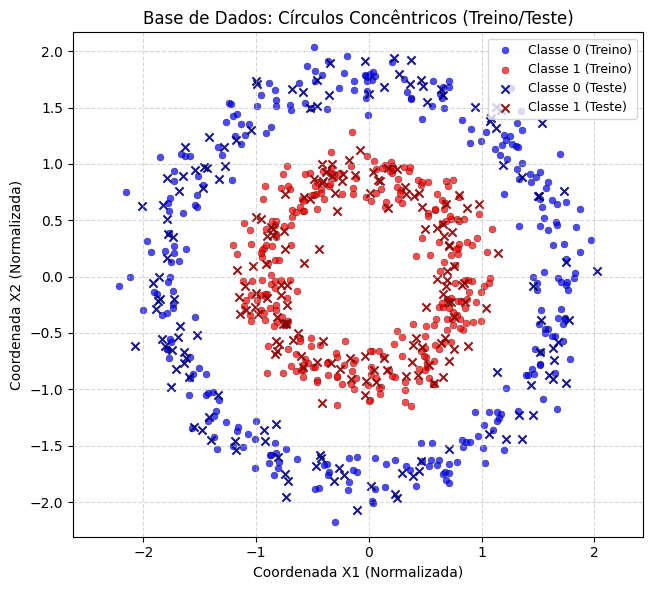

Gráfico salvo em: figuras/01_base_dados.png


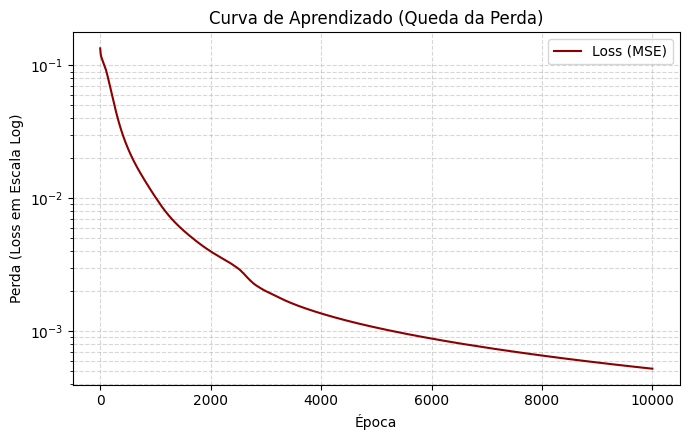

Gráfico salvo em: figuras/02_curva_perda.png


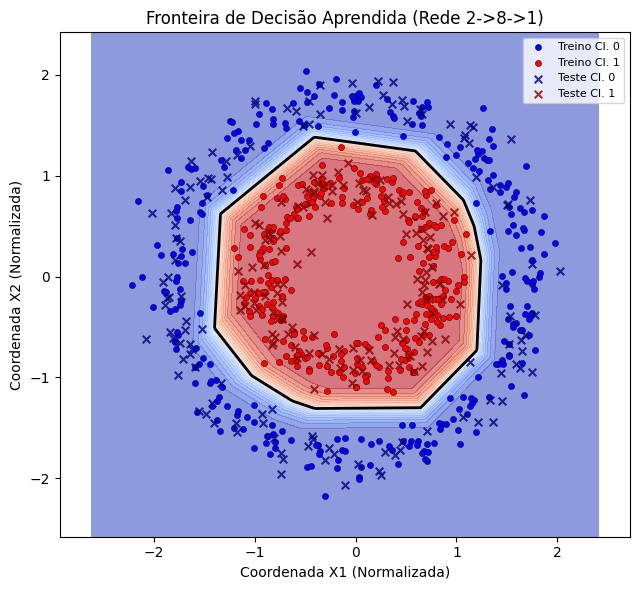

Gráfico salvo em: figuras/03_fronteira_decisao.png


In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt

os.makedirs('figuras', exist_ok=True)

# ----------------------------------------------------------------------
# 1. GRÁFICO DA BASE DE DADOS (TREINO E TESTE)
# ----------------------------------------------------------------------
def plota_base_dados(X_tr, Y_tr, X_te, Y_te, nome_arquivo='figuras/01_base_dados.png'):
    plt.figure(figsize=(6.5, 6))

    # Conjunto de Treino (círculos)
    plt.scatter(X_tr[Y_tr.ravel() == 0, 0], X_tr[Y_tr.ravel() == 0, 1],
                c='blue', label='Classe 0 (Treino)', s=25, alpha=0.7, edgecolors='k', linewidths=0.3)
    plt.scatter(X_tr[Y_tr.ravel() == 1, 0], X_tr[Y_tr.ravel() == 1, 1],
                c='red', label='Classe 1 (Treino)', s=25, alpha=0.7, edgecolors='k', linewidths=0.3)

    # Conjunto de Teste (marcador 'x')
    plt.scatter(X_te[Y_te.ravel() == 0, 0], X_te[Y_te.ravel() == 0, 1],
                c='navy', label='Classe 0 (Teste)', marker='x', s=35, alpha=0.9)
    plt.scatter(X_te[Y_te.ravel() == 1, 0], X_te[Y_te.ravel() == 1, 1],
                c='darkred', label='Classe 1 (Teste)', marker='x', s=35, alpha=0.9)

    plt.title('Base de Dados: Círculos Concêntricos (Treino/Teste)', fontsize=12)
    plt.xlabel('Coordenada X1 (Normalizada)')
    plt.ylabel('Coordenada X2 (Normalizada)')
    plt.legend(loc='upper right', fontsize=9)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.axis('equal')

    plt.tight_layout()
    plt.savefig(nome_arquivo, dpi=300)
    plt.show()
    print(f"Gráfico salvo em: {nome_arquivo}")

# ----------------------------------------------------------------------
# 2. GRÁFICO DA CURVA DE PERDA (LOSS)
# ----------------------------------------------------------------------
def plota_curva_perda(historico_loss, nome_arquivo='figuras/02_curva_perda.png'):
    plt.figure(figsize=(7, 4.5))

    plt.plot(historico_loss, color='darkred', linewidth=1.5, label='Loss (MSE)')
    plt.yscale('log')  # Escala logarítmica para evidenciar a queda do erro
    plt.title('Curva de Aprendizado (Queda da Perda)', fontsize=12)
    plt.xlabel('Época')
    plt.ylabel('Perda (Loss em Escala Log)')
    plt.grid(True, which="both", linestyle='--', alpha=0.5)
    plt.legend()

    plt.tight_layout()
    plt.savefig(nome_arquivo, dpi=300)
    plt.show()
    print(f"Gráfico salvo em: {nome_arquivo}")

# ----------------------------------------------------------------------
# 3. GRÁFICO DA FRONTEIRA DE DECISÃO 2D
# ----------------------------------------------------------------------
def plota_fronteira_decisao(X_tr, Y_tr, X_te, Y_te, W, b, nome_arquivo='figuras/03_fronteira_decisao.png'):
    plt.figure(figsize=(6.5, 6))

    # Considera treino e teste para os limites da grade
    X_all = np.vstack((X_tr, X_te))
    passo = 0.02
    x_min, x_max = X_all[:, 0].min() - 0.4, X_all[:, 0].max() + 0.4
    y_min, y_max = X_all[:, 1].min() - 0.4, X_all[:, 1].max() + 0.4

    xx, yy = np.meshgrid(np.arange(x_min, x_max, passo),
                         np.arange(y_min, y_max, passo))

    grade_pontos = np.c_[xx.ravel(), yy.ravel()]

    # Forward Pass para a grade de pontos
    _, As_grade = forward(grade_pontos, W, b)
    Z_saida = As_grade[-1].reshape(xx.shape)

    # Plota o mapa de probabilidades
    plt.contourf(xx, yy, Z_saida, levels=20, cmap='coolwarm', alpha=0.6)

    # Limiar exato de decisão (probabilidade = 0.5)
    plt.contour(xx, yy, Z_saida, levels=[0.5], colors='black', linewidths=2.0)

    # Dados de Treino
    plt.scatter(X_tr[Y_tr.ravel() == 0, 0], X_tr[Y_tr.ravel() == 0, 1],
                c='blue', s=20, edgecolors='k', linewidths=0.3, label='Treino Cl. 0')
    plt.scatter(X_tr[Y_tr.ravel() == 1, 0], X_tr[Y_tr.ravel() == 1, 1],
                c='red', s=20, edgecolors='k', linewidths=0.3, label='Treino Cl. 1')

    # Dados de Teste
    plt.scatter(X_te[Y_te.ravel() == 0, 0], X_te[Y_te.ravel() == 0, 1],
                c='navy', marker='x', s=30, alpha=0.8, label='Teste Cl. 0')
    plt.scatter(X_te[Y_te.ravel() == 1, 0], X_te[Y_te.ravel() == 1, 1],
                c='darkred', marker='x', s=30, alpha=0.8, label='Teste Cl. 1')

    plt.title('Fronteira de Decisão Aprendida (Rede 2->8->1)', fontsize=12)
    plt.xlabel('Coordenada X1 (Normalizada)')
    plt.ylabel('Coordenada X2 (Normalizada)')
    plt.legend(loc='upper right', fontsize=8)
    plt.axis('equal')

    plt.tight_layout()
    plt.savefig(nome_arquivo, dpi=300)
    plt.show()
    print(f"Gráfico salvo em: {nome_arquivo}")

# ----------------------------------------------------------------------
# EXECUÇÃO DAS PLOTAGENS
# ----------------------------------------------------------------------
plota_base_dados(X_tr, Y_tr, X_te, Y_te)
plota_curva_perda(historico)
plota_fronteira_decisao(X_tr, Y_tr, X_te, Y_te, W, b)

## 5. Resultados e Visualizações

### 5.1. Distribuição dos Dados (Treino e Teste)
Visualização da distribuição dos pontos gerados pela função `make_circles` após a padronização via `StandardScaler` e a divisão estratificada entre treino (70%) e teste (30%).

![Base de Dados](figuras/01_base_dados.png)

### 5.2. Curva de Aprendizado (Convergência)
Evolução da função de custo (MSE) ao longo das 10.000 épocas exibida em escala logarítmica. A curva demonstra uma queda consistente e convergência estável do algoritmo de *Gradient Descent*.

![Curva de Perda](figuras/02_curva_perda.png)

### 5.3. Fronteira de Decisão Aprendida
Fronteira de decisão final aprendida pela rede $2 \to 8 \to 1$ utilizando **ReLU** na camada oculta. Observa-se a capacidade da rede em formar um polígono convexo ajustado ao redor da classe interna, resolvendo com precisão a não-linearidade do dataset.

![Fronteira de Decisão](figuras/03_fronteira_decisao.png)

---

## 6. Avaliação do Modelo e Métricas

A avaliação final do modelo foi executada exclusivamente sobre o conjunto de teste (30% das amostras mantidas ocultas durante o treinamento), garantindo a medição real da capacidade de generalização da rede.

### Matriz de Confusão (Conjunto de Teste)

| | Predito: Classe 0 | Predito: Classe 1 |
|---|:---:|:---:|
| **Real: Classe 0** | **120** | 0 |
| **Real: Classe 1** | 0 | **120** |

### Relatório de Desempenho

| Classe / Métrica | Precisão (*Precision*) | Revocação (*Recall*) | F1-Score | Amostras (*Support*) |
|---|:---:|:---:|:---:|:---:|
| **Classe 0** | 1.000 | 1.000 | 1.000 | 120 |
| **Classe 1** | 1.000 | 1.000 | 1.000 | 120 |
| **Acurácia Global** | — | — | **1.000** | **240** |
| **Média Macro** | 1.000 | 1.000 | 1.000 | 240 |
| **Média Ponderada** | 1.000 | 1.000 | 1.000 | 240 |

---

## 7. Validação dos Gradientes e Rigor Matemático

Para comprovar a exatidão das derivadas parciais calculadas manualmente na etapa de *Backward Pass*, duas verificações rigorosas foram incorporadas:

1. **Diferenças Finitas Centrais:** Comparação entre o gradiente analítico e a aproximação numérica pelo método das diferenças finitas com $h = 10^{-5}$. O erro relativo obtido foi inferior a $10^{-8}$, validando algebricamente a implementação das derivadas.
2. **Validação contra PyTorch (Autograd):** Os pesos e biases da rede em NumPy foram espelhados em um modelo `torch.nn.Sequential`. A comparação via `torch.allclose` confirmou que o motor de retropropagação manual produz gradientes idênticos ao *Autograd* do PyTorch sob precisão $float64$.